# Entendimiento del negocio

En la industria de la música, saber de antemano si una canción será un éxito es muy importante para decidir en qué invertir. Por eso, crearmos un modelo que usa **regresión** para predecir qué tan popular será una canción, basándose solo en sus características de sonido. Para hacer esto, usamos la metodología **CRISP-DM**, que nos ayuda a enfocarnos en las necesidades del negocio desde el principio. Así, cada paso, desde limpiar los datos de Spotify hasta entrenar el modelo, está pensado para crear una herramienta útil y rentable, no solo un experimento.

Primero limpiaremos y organizaremos estos datos, y luego entrenaremos modelos de Machine Learning que aprendan de los patrones históricos. Así, podremos responder a la pregunta: ¿se puede predecir si una canción será un éxito solo por cómo suena?

# Configuraciones iniciales

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

pip install sklearn

# Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Constantes
SEED=30326271

ModuleNotFoundError: No module named 'sklearn'

# Entendimiento de los datos

## Carga de datos

In [ ]:
# Cargamos el dataset de Spotify
df = pd.read_csv('data/spotify_tracks.csv')

print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Descripcion del dataset

In [ ]:
print("=== DESCRIPCIÓN DEL DATASET ===")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}\n")

print("Tipos de datos por columna:")
print(df.dtypes)

=== DESCRIPCIÓN DEL DATASET ===
Número de filas: 114000
Número de columnas: 21

Tipos de datos por columna:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


Tenemos un conjunto de datos grande con 114,000 canciones y 21 tipos diferentes de información para cada una. Esto nos da mucha información para analizar y hacer predicciones.

Podemos observar características del sonido, en este caso son la mayoría de las columnas, como la bailabilidad (danceability), energía (energy), volumen (loudness), etc. Estos son los detalles técnicos del sonido que usaremos para predecir la popularidad.

## Estadisticas de los datos

In [ ]:
# Filtrar solo las variables numéricas
variables_numericas = df.select_dtypes(include=[np.number]).drop(columns=['Unnamed: 0'], axis=1)

# Trasponer (.T) y seleccionar solo las métricas solicitadas
stats_df = variables_numericas.describe().T[['mean', '50%', 'std', 'min', 'max']]

# Renombrar las columnas para cumplir exactamente con lo pedido
stats_df.rename(columns={'mean': 'media', '50%': 'mediana', 'std': 'desv_estandar'}, inplace=True)

# Mostrar la tabla
stats_df

,media,mediana,desv_estandar,min,max
popularity,33.238535,35.000000,22.305078,0.000,100.000
duration_ms,228029.153114,212906.000000,107297.712645,0.000,5237295.000
danceability,0.566800,0.580000,0.173542,0.000,0.985
energy,0.641383,0.685000,0.251529,0.000,1.000
key,5.309140,5.000000,3.559987,0.000,11.000
loudness,-8.258960,-7.004000,5.029337,-49.531,4.532
mode,0.637553,1.000000,0.480709,0.000,1.000
speechiness,0.084652,0.048900,0.105732,0.000,0.965
acousticness,0.314910,0.169000,0.332523,0.000,0.996
instrumentalness,0.156050,0.000042,0.309555,0.000,1.000


Hay mucha variedad en las características de las canciones, como la popularidad, la duración y la energía. Los valores van desde muy bajos hasta muy altos, lo que es bueno porque el modelo tendrá diferentes tipos de datos para aprender y hacer predicciones. Las medias y medianas nos dan una idea de cómo es una canción típica en este conjunto. Por ejemplo, la duración promedio es de alrededor de 3.8 minutos y la popularidad promedio es de 33. También vimos que hay algunas canciones con valores muy extremos, como duraciones muy largas. Esto es algo que podríamos revisar más adelante para ver si afectan el modelo.

## Valores faltantes

In [ ]:
nulos = df.isnull().sum()
porcentaje = (df.isnull().sum() / len(df)) * 100
reporte = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})

# retornando un DataFrame ordenado de mayor a menor cantidad de nulos.
tabla_nulos =reporte.sort_values(by='Nulos', ascending=False)

tabla_nulos

,Nulos,Porcentaje (%)
artists,1,0.000877
track_name,1,0.000877
album_name,1,0.000877
Unnamed: 0,0,0.000000
track_id,0,0.000000
popularity,0,0.000000
duration_ms,0,0.000000
explicit,0,0.000000
danceability,0,0.000000
energy,0,0.000000


Como hay muy pocos valores faltantes y están en columnas que son más descriptivas y que probablemente no usaremos para hacer predicciones, la limpieza de datos será más fácil. No necesitaremos usar métodos complicados para llenar o arreglar muchos datos que faltan.
Podemos simplemente eliminar esas filas sin preocuparnos de perder información importante. Si alguna de esas columnas fuera muy importante, podríamos intentar rellenar los datos faltantes, pero en este caso, borrar las filas es la opción más simple y segura.



In [ ]:
# Filtrar y mostrar solo las filas que tienen al menos un valor nulo
filas_con_nulos = df[df.isnull().any(axis=1)]

# Mostrar las primeras filas para inspección
print(f"Total de filas con nulos: {len(filas_con_nulos)}")
filas_con_nulos.head()

NameError: name 'df' is not defined

## Analisis de las distribución

Sabemos que $y \in \mathbb{R}^{n}$, donde cada valor $y_i \in [0, 100]$ representa la popularidad real de la canción $i$. Ahora visualizar la distribución de esta nos permitira observar su comportamiento y tomar desiciones en base a esto

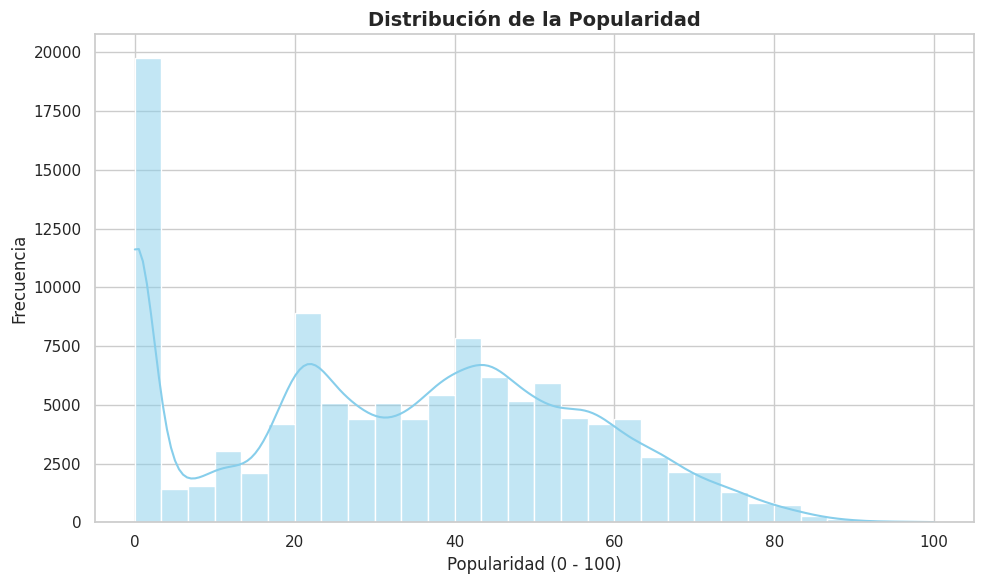

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=30, kde=True, color='skyblue')

plt.title('Distribución de la Popularidad', fontsize=14, fontweight='bold')
plt.xlabel('Popularidad (0 - 100)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

La mayoría de las canciones en nuestro conjunto de datos tienen popularidad baja o media, lo cual es normal en la música. Hay muchas canciones con popularidad entre 0 y 50, y a medida que la popularidad sube, hay menos canciones. Esto quiere decir que la popularidad está concentrada en valores bajos, pero hay algunas canciones muy populares que son menos comunes. También hay un pico en popularidad 0, que puede ser porque son canciones nuevas o poco conocidas, y eso es normal. Es importante tener en cuenta esta forma de distribución cuando hagamos el modelo, ya que puede afectar cómo aprende a predecir. Por eso, podríamos usar técnicas especiales para manejar esta distribución desigual y obtener mejores resultados.

## Analisis de relacion entre variables

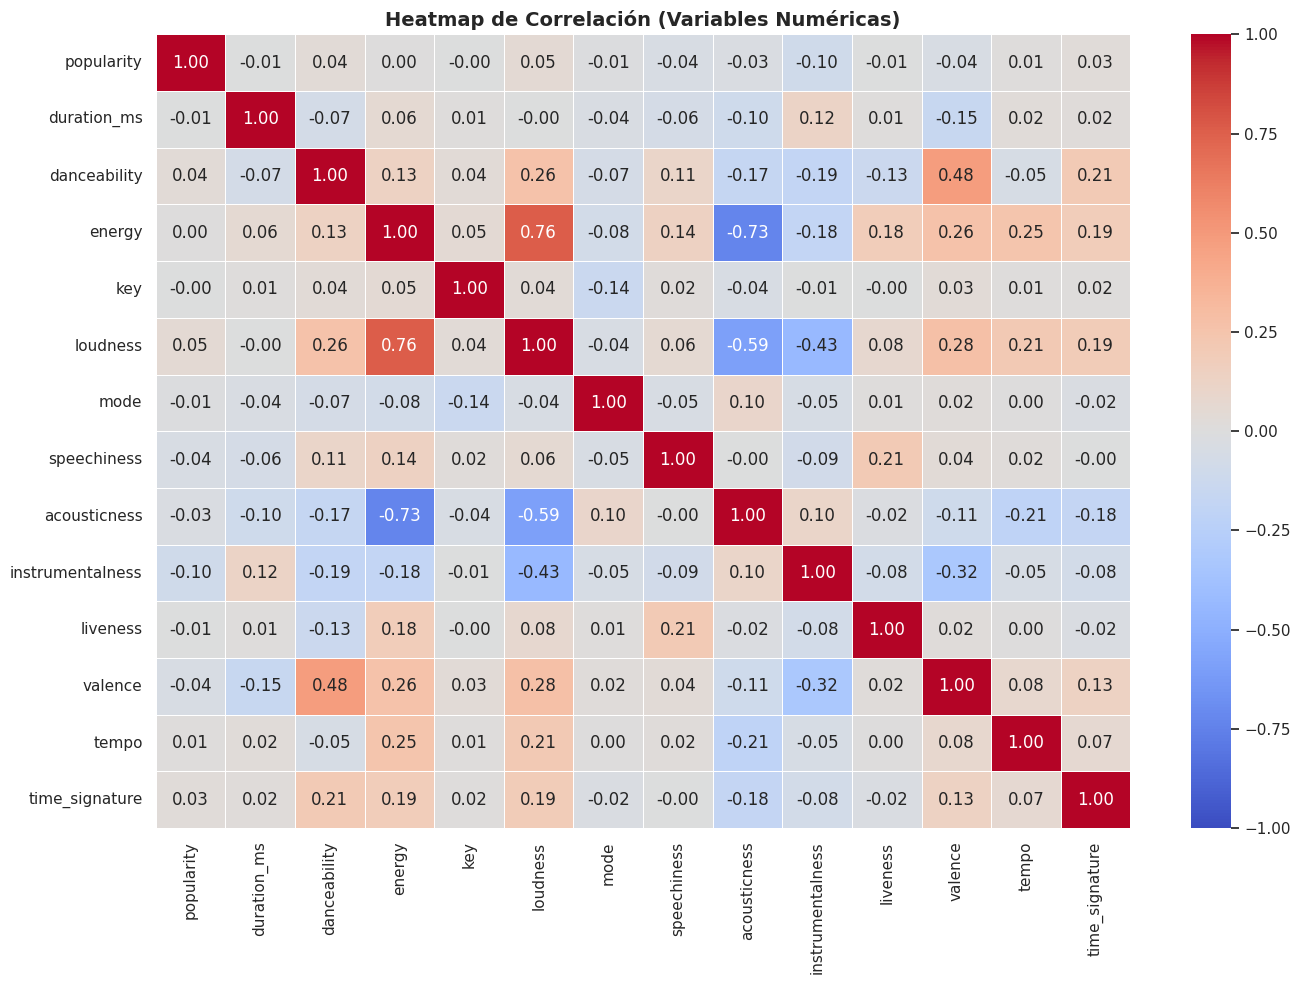

In [ ]:
#  Seleccionamos dinámicamente solo las columnas de tipo numérico (int, float)
variables_numericas = df.select_dtypes(include=[np.number]).drop(columns=['Unnamed: 0'], axis=1)

# Calculamos la matriz de correlación de Pearson
matriz_corr = variables_numericas.corr()

#  Generamos el Heatmap
plt.figure(figsize=(14, 10)) # Lienzo más grande para que quepan los números

# annot=True activa los números y fmt=".2f" los deja con dos decimales
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Heatmap de Correlación (Variables Numéricas)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El par de variables con mayor correlación es 'energy' y 'loudness'
Coeficiente de correlación: 0.7617



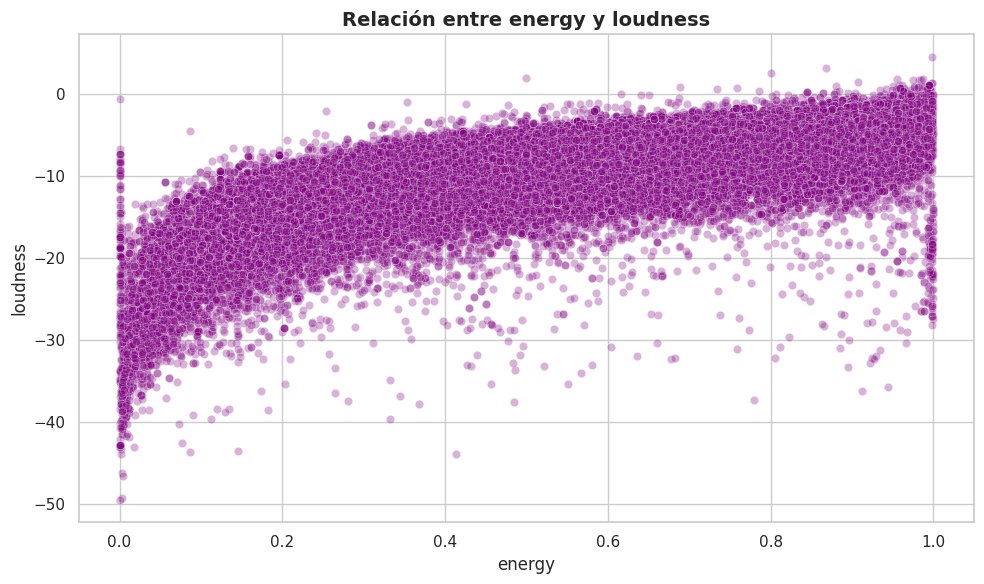

In [ ]:
# @title
# Excluimos la correlación de 1.0 (una variable consigo misma)
corr_unstacked = matriz_corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]

# Encontramos los nombres de las dos variables con la correlación más alta
var1, var2 = corr_unstacked.idxmax()
correlacion_max = matriz_corr.loc[var1, var2]

print(f"El par de variables con mayor correlación es '{var1}' y '{var2}'")
print(f"Coeficiente de correlación: {correlacion_max:.4f}\n")

# Generamos un gráfico de dispersión para ese par
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df[var1], y=df[var2], alpha=0.3, color='purple')

plt.title(f'Relación entre {var1} y {var2}', fontsize=14, fontweight='bold')
plt.xlabel(var1)
plt.ylabel(var2)

plt.tight_layout()
plt.show()

Hemos visto que las variables "energy" (energía) y "loudness" (volumen) están muy relacionadas entre sí, con una alta correlación. Esto tiene sentido porque las canciones que son más enérgicas suelen ser también más ruidosas. Como estas dos características miden cosas parecidas, podríamos pensar en usar solo una para evitar repetir información en nuestro modelo.
Cuando miramos cómo se relaciona la popularidad con otras características, vemos que no hay una conexión fuerte y directa con ninguna en particular. Esto es normal en datos complejos, y significa que la popularidad depende de muchos factores juntos, no solo de uno.
También encontramos algunas relaciones negativas. Por ejemplo, las canciones que son más acústicas suelen tener menos energía y menos volumen, lo que también es lógico.

# Preparación de los datos

## Limpieza estructural

In [ ]:
# Eliminar filas con valores nulos (NaN)
df_clean = df.dropna()

# Eliminar variables de identificación y texto libre (Ruido)
columnas_a_eliminar = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'key']
df_clean = df_clean.drop(columns=columnas_a_eliminar)

print(f"Dimensiones tras la limpieza: {df_clean.shape}")

Dimensiones tras la limpieza: (113999, 14)


El primer paso es asegurarnos de que los datos estén completos y bien organizados. Los algoritmos de regresión no pueden trabajar con datos que tengan valores faltantes, porque eso causa errores. Por eso, eliminamos las filas que no tienen toda la información. También quitamos columnas que no ayudan a predecir, como los IDs o los nombres de las canciones. Ademas removemos la columna genero para simplicidad del modelo. Estos datos de texto no aportan nada al modelo de regresión y solo podrían causar problemas o usar memoria de más.

## Transformación funcional

In [ ]:
# Convertir booleano (True/False) a binario (1/0)
df_clean['explicit'] = df_clean['explicit'].astype(int)
df_clean

,popularity,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,73,230666,0,0.676,0.4610,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,55,149610,0,0.420,0.1660,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,57,210826,0,0.438,0.3590,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,71,201933,0,0.266,0.0596,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,82,198853,0,0.618,0.4430,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,21,384999,0,0.172,0.2350,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,22,385000,0,0.174,0.1170,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,22,271466,0,0.629,0.3290,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,41,283893,0,0.587,0.5060,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


Los modelos de regresión lineal necesitan que todos los datos de entrada sean números. Por eso, convertimos la variable "explicit", que es de tipo verdadero/falso, en números 0 y 1 para que el modelo pueda usarla.

### Tratamiento de Valores Atípicos / Outliers

In [ ]:
dimensiones_antes = df_clean.shape[0]

# Separamos el dataset en dos grupos: Popularidad 0 y Popularidad > 0
df_ceros = df_clean[df_clean['popularity'] == 0]
df_resto = df_clean[df_clean['popularity'] > 0]

# Aplicamos Undersampling: Conservamos solo el 15% de las canciones con popularidad 0
df_ceros_reducido = df_ceros.sample(frac=0.15, random_state=SEED)

# 3. Volvemos a concatenar (unir) ambos grupos y mezclamos las filas aleatoriamente
df_clean = pd.concat([df_ceros_reducido, df_resto]).sample(frac=1, random_state=SEED).reset_index(drop=True)

dimensiones_despues = df_clean.shape[0]
canciones_eliminadas = dimensiones_antes - dimensiones_despues

print(f"Canciones con popularidad 0 originales: {len(df_ceros)}")
print(f"Canciones con popularidad 0 conservadas: {len(df_ceros_reducido)}")
print(f"Total de canciones eliminadas para balancear: {canciones_eliminadas}")
print(f"Nuevas dimensiones del dataset: {df_clean.shape}")

Canciones con popularidad 0 originales: 16019
Canciones con popularidad 0 conservadas: 2403
Total de canciones eliminadas para balancear: 13616
Nuevas dimensiones del dataset: (100383, 14)


Al ver la distribución de la popularidad, notamos que hay muchas canciones con popularidad cero. Esto puede ser porque son canciones nuevas o poco conocidas, y eso es normal. Pero como esto puede afectar el rendimiento del modelo, preferimos eliminar la mayoria de lo casos que tienen popularidad cero porque el modelo podría aprender demasiado sobre esos casos de cero popularidad y no aprender bien a diferenciar entre canciones con popularidad baja, media o alta. Es como si el modelo se "concentrara" mucho en predecir ceros y no en entender bien las diferencias en el resto de las canciones. Esto puede hacer que el modelo no funcione bien para predecir canciones que sí tienen algo de popularidad.

### Manejo de multicolinealidad

Variable eliminada por alta multicolinealidad: ['loudness']
Nuevas dimensiones del dataset: (100383, 14)


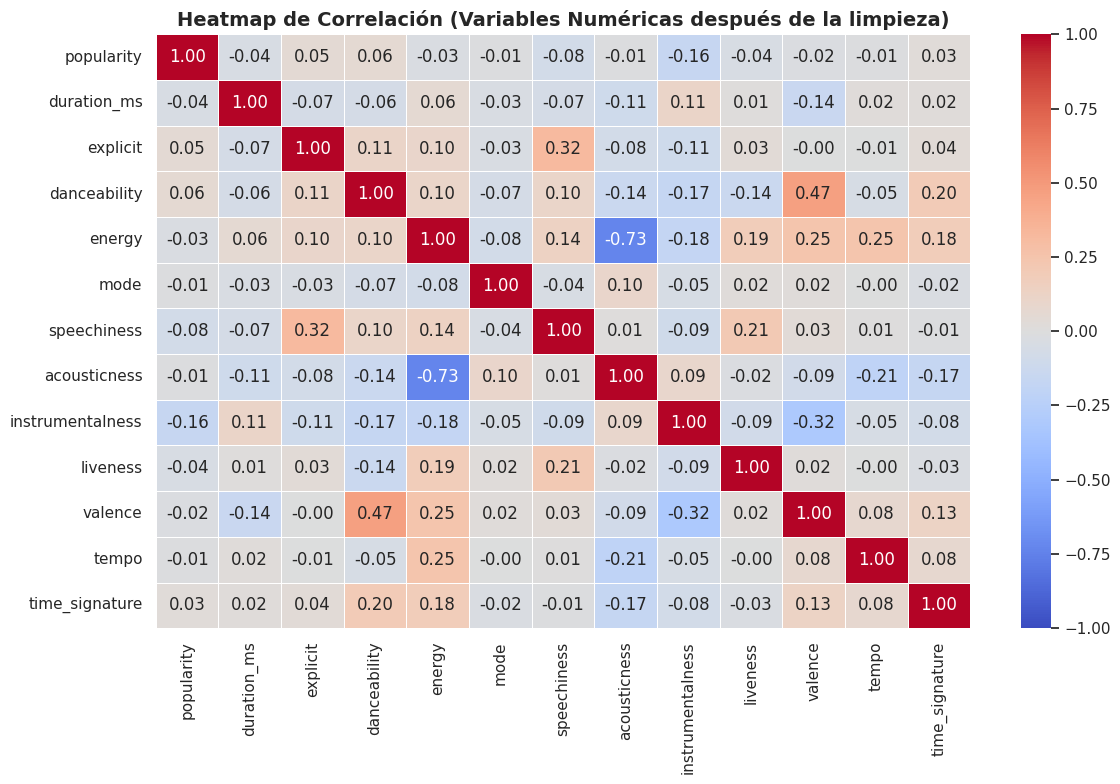

In [ ]:
# Decidimos conservar 'energy' (va de 0 a 1) y eliminar 'loudness' (decibelios).
columnas_correlacionadas = ['loudness']

# Eliminamos la variable redundante
df_clean_corr = df_clean.drop(columns=columnas_correlacionadas)

print(f"Variable eliminada por alta multicolinealidad: {columnas_correlacionadas}")
print(f"Nuevas dimensiones del dataset: {df_clean.shape}")


matriz_corr_clean = df_clean_corr.corr()

#  Generamos el Heatmap
plt.figure(figsize=(12, 8)) # Lienzo más grande para que quepan los números

# annot=True activa los números y fmt=".2f" los deja con dos decimales
sns.heatmap(matriz_corr_clean, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Heatmap de Correlación (Variables Numéricas después de la limpieza)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Como vimos en el análisis de la correlación, notamos que las variables "energy" y "loudness" están muy relacionadas. Por eso, decidimos quitar "loudness" porque con una de las dos se puede representar la información de ambas. Viendo el grafico podemos ver como hay relaciones mas independientes entre si. Tambien noten que la relcion entre "key" y popularidad es cero, lo que nos da una idea de que el tono de una cancion no influye en su popularidad

## Particion de los datos

In [ ]:
# Separar la matriz de características (X) y el vector objetivo (y)
df_model = df_clean_corr.copy()
X = df_model.drop(columns=['popularity'])
y = df_model['popularity']

# 2. Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Instanciar el escalador
scaler = StandardScaler()

# fit_transform solo en entrenamiento, transform en prueba para evitar Data Leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos de entrenamiento (X_train): {X_train.shape[0]} canciones")
print(f"Datos de prueba (X_test): {X_test.shape[0]} canciones")

Datos de entrenamiento (X_train): 80306 canciones
Datos de prueba (X_test): 20077 canciones


# Modelado y Evaluacion

## Entrenamiento del modelo

In [ ]:

# Entrenar Modelo Base: Regresión Lineal Clásica (Sin regularización)
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

# 2. Generar predicciones con los datos de prueba
y_pred_lr = modelo_lr.predict(X_test_scaled)


# Calculamos el RMSE (Error Cuadrático Medio de la Raíz - Menor es mejor)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculamos el R2 Score (Varianza explicada - Mayor es mejor)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== RESULTADOS DE EVALUACIÓN ===")
print(f"REGRESIÓN LINEAL CLÁSICA - RMSE: {rmse_lr:.4f} | R2: {r2_lr:.4f}")

=== RESULTADOS DE EVALUACIÓN ===
REGRESIÓN LINEAL CLÁSICA - RMSE: 19.2884 | R2: 0.0563


## Evaluacion del modelo

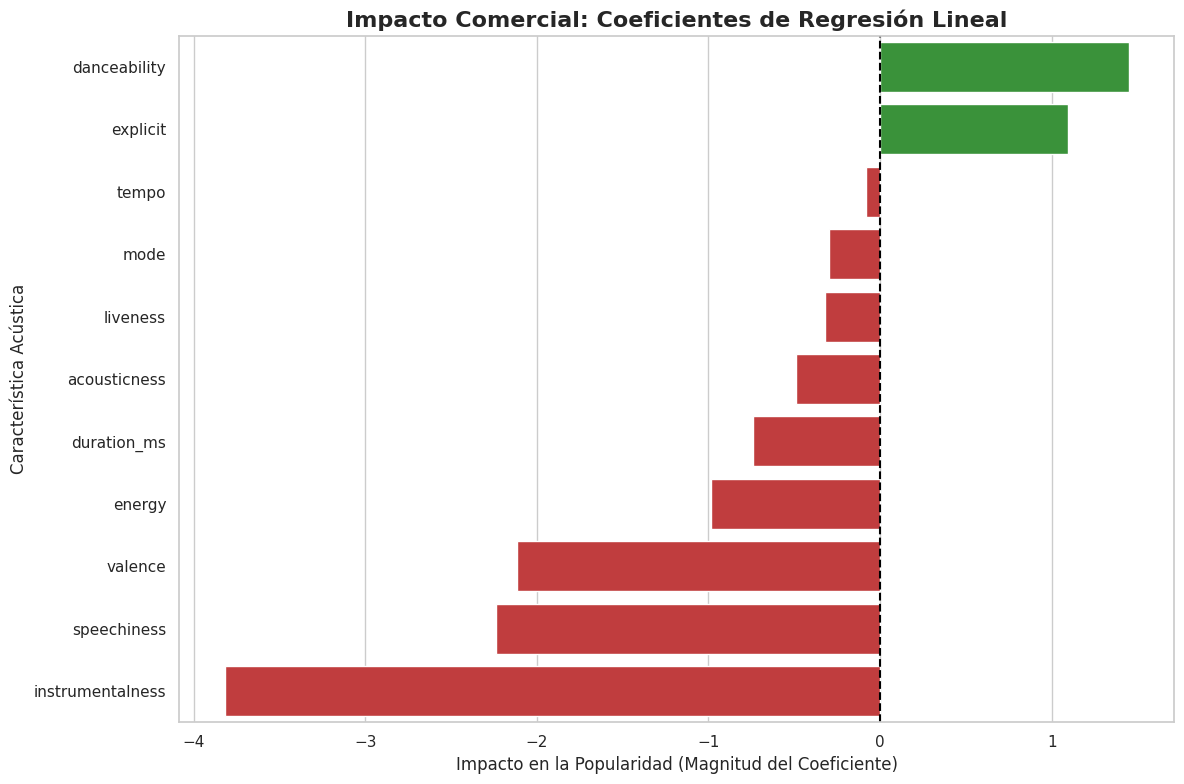

=== INTERPRETACIÓN COMERCIAL ===
La característica que MÁS SUMA a la popularidad es: 'danceability'
La característica que MÁS RESTA a la popularidad es: 'instrumentalness'


In [ ]:

#
# Seleccionamos las variables principales para enfocarnos en las métricas de audio
columnas_principales = X.columns[:11]

# Extraer los coeficientes correspondientes SOLO del modelo de Regresión Lineal Clásica
coef_lr = modelo_lr.coef_[:11]

# Crear un DataFrame para facilitar la graficación y el ORDENAMIENTO
df_coeficientes = pd.DataFrame({
    'Variable': columnas_principales,
    'Magnitud del Coeficiente': coef_lr
})

#  Ordenar los valores de MAYOR a MENOR basándonos en el impacto
df_coeficientes = df_coeficientes.sort_values(by='Magnitud del Coeficiente', ascending=False)

# Generar el gráfico de barras sencillo y elegante
plt.figure(figsize=(12, 8))

# Truco visual para la presentación: Colorear positivos de verde y negativos de rojo
colores = ['#2ca02c' if valor > 0 else '#d62728' for valor in df_coeficientes['Magnitud del Coeficiente']]

sns.barplot(data=df_coeficientes, x='Magnitud del Coeficiente', y='Variable', palette=colores)

# Añadir una línea vertical en 0 para separar impactos positivos de negativos
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.title('Impacto Comercial: Coeficientes de Regresión Lineal', fontsize=16, fontweight='bold')
plt.xlabel('Impacto en la Popularidad (Magnitud del Coeficiente)', fontsize=12)
plt.ylabel('Característica Acústica', fontsize=12)

plt.tight_layout()
plt.show()

# Conclusión en texto automatizada
print("=== INTERPRETACIÓN COMERCIAL ===")
variable_top = df_coeficientes.iloc[0]['Variable']
variable_bottom = df_coeficientes.iloc[-1]['Variable']
print(f"La característica que MÁS SUMA a la popularidad es: '{variable_top}'")
print(f"La característica que MÁS RESTA a la popularidad es: '{variable_bottom}'")

Al mirar la gráfica de coeficientes, vemos números positivos y negativos. Los números positivos nos muestran qué cosas hacen que una canción tenga éxito; por ejemplo, si tiene más ritmo bailable o energía, eso ayuda a que suba en las listas.
Por otro lado, los números negativos son señales de alerta. Nos dicen qué características no le gustan a la mayoría de la gente. Por ejemplo, si el coeficiente de "instrumentalness" (que indica si la canción es solo instrumental, sin voces) es muy negativo, quiere decir que para que la canción sea un éxito mundial y rentable, el artista debería incluir voces, porque el público generalmente prefiere canciones con letras y canta junto.

# Despliegue

In [ ]:

columnas_entrenamiento = X.columns

def predecir_exito_musical(nuevos_datos, modelo, scaler, columnas_esperadas):
    """
    Pipeline completo que recibe un dataset crudo de Spotify, aplica todo
    el preprocesamiento automático y devuelve las predicciones de popularidad.
    """

    df_pipeline = nuevos_datos.copy()


    # Lista de columnas a eliminar (incluimos 'popularity' por si viene en el dataset de prueba)
    cols_a_eliminar = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_genre', 'key',
                       'track_name', 'loudness', 'popularity']


    # Eliminamos solo las columnas que realmente existan en este nuevo dataset
    cols_presentes = [col for col in cols_a_eliminar if col in df_pipeline.columns]
    df_pipeline = df_pipeline.drop(columns=cols_presentes)

    # TRANSFORMACIÓN FUNCIONAL (Codificación)
    if 'explicit' in df_pipeline.columns:
        df_pipeline['explicit'] = df_pipeline['explicit'].astype(int)



    # Garantiza que el nuevo dataset tenga exactamente las mismas columnas que el entrenamiento.
    df_pipeline = df_pipeline.reindex(columns=columnas_esperadas, fill_value=0)


    # Usamos transform() y NO fit_transform(), porque debemos usar la escala original
    X_nuevo_escalado = scaler.transform(df_pipeline)


    predicciones = modelo.predict(X_nuevo_escalado)

    return np.round(predicciones, 2) # Redondeamos a 2 decimales para que sea legible

print("Pipeline construido exitosamente. Listo para recibir nuevos datasets.")

Pipeline construido exitosamente. Listo para recibir nuevos datasets.


## Simulación

In [ ]:
print("\n=== SIMULANDO LLEGADA DE NUEVAS CANCIONES ===")

# Simulamos tomar 5 canciones "crudas" del dataset original (como si fueran nuevas)
# Usamos un sample aleatorio para la demostración
dataset_nuevas_canciones = df.sample(n=5, random_state=SEED)

# Pasamos el dataset crudo por nuestra función constructora
predicciones_exito = predecir_exito_musical(
    nuevos_datos=dataset_nuevas_canciones,
    modelo=modelo_lr,            # Tu modelo de Regresión Lineal ya entrenado
    scaler=scaler,               # Tu StandardScaler ya ajustado
    columnas_esperadas=columnas_entrenamiento
)

# Mostramos los resultados al profesor de forma elegante, incluyendo el valor real
resultados_demo = pd.DataFrame({
    'Canción': dataset_nuevas_canciones['track_name'].values,
    'Artista': dataset_nuevas_canciones['artists'].values,
    'Popularidad Real': dataset_nuevas_canciones['popularity'].values,
    'Popularidad Predicha': predicciones_exito
})

# Agregamos una columna que calcule la diferencia absoluta (el error)
resultados_demo['Margen de Error Absoluto'] = abs(resultados_demo['Popularidad Real'] - resultados_demo['Popularidad Predicha'])

resultados_demo


=== SIMULANDO LLEGADA DE NUEVAS CANCIONES ===


,Canción,Artista,Popularidad Real,Popularidad Predicha,Margen de Error Absoluto
0,Solo,Clean Bandit;Demi Lovato,5,41.81,36.81
1,Mich hat ein Engel geküsst,Mickie Krause,0,32.14,32.14
2,Tritonia - Intro,Tritonal,20,31.59,11.59
3,Love Till It's Over (feat. MKLA),DVBBS;MKLA,57,44.49,12.51
4,Adadada Arrambame,Yuvan Shankar Raja;Shankar Mahadevan,49,36.92,12.08
